## Web scrapping

In [10]:
import requests
from bs4 import BeautifulSoup
import re

In [11]:
url = "https://www.gutenberg.org/cache/epub/84/pg84-images.html"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, "html.parser")

text = soup.get_text()

start_marker = "To Mrs. Saville, England."
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK FRANKENSTEIN; OR, THE MODERN PROMETHEUS ***"

start = text.find(start_marker)
end = text.find(end_marker)

if start != -1:
    text = text[start + len(start_marker):]

if end != -1:
    text = text[:end]

print(text[:2000])




St. Petersburgh, Dec. 11th, 17—.


You will rejoice to hear that no disaster has accompanied the commencement of
an enterprise which you have regarded with such evil forebodings. I arrived
here yesterday, and my first task is to assure my dear sister of my welfare and
increasing confidence in the success of my undertaking.


I am already far north of London, and as I walk in the streets of Petersburgh,
I feel a cold northern breeze play upon my cheeks, which braces my nerves and
fills me with delight. Do you understand this feeling? This breeze, which has
travelled from the regions towards which I am advancing, gives me a foretaste
of those icy climes. Inspirited by this wind of promise, my daydreams become
more fervent and vivid. I try in vain to be persuaded that the pole is the seat
of frost and desolation; it ever presents itself to my imagination as the
region of beauty and delight. There, Margaret, the sun is for ever visible, its
broad disk just skirting the horizon and diffu

## Text Preprocessing

In [12]:
text = re.sub(r'\n\s*(letter|chapter)\s+\d+\s*\n', '\n', text, flags=re.IGNORECASE)

text = re.sub(
    r'(^|\n)[A-Za-z.\- ]*,?\s*(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\.?\,?\s*(\d{1,2}(st|nd|rd|th)?)?,?\s*(17—\.)?\s*',
    r'\1',
    text
)

text = text.lower()
text = re.sub(r'\s+', ' ', text)
text = text.strip()

print(text[:2000])

you will rejoice to hear that no disaster has accompanied the commencement of an enterprise which you have regarded with such evil forebodings. i arrived here yesterday, and my first task is to assure my dear sister of my welfare and increasing confidence in the success of my undertaking. i am already far north of london, and as i walk in the streets of petersburgh, i feel a cold northern breeze play upon my cheeks, which braces my nerves and fills me with delight. do you understand this feeling? this breeze, which has travelled from the regions towards which i am advancing, gives me a foretaste of those icy climes. inspirited by this wind of promise, my daydreams become more fervent and vivid. i try in vain to be persuaded that the pole is the seat of frost and desolation; it ever presents itself to my imagination as the garet, the sun is for ever visible, its broad disk just skirting the horizon and diffusing a perpetual splendour. there—for with your leave, my sister, i will put som

In [13]:
text = re.sub(r'([.!?])', r'\1 <END>', text)

text = re.sub(r'[^\w\s<>]', '', text)

print(text[:2000])

you will rejoice to hear that no disaster has accompanied the commencement of an enterprise which you have regarded with such evil forebodings <END> i arrived here yesterday and my first task is to assure my dear sister of my welfare and increasing confidence in the success of my undertaking <END> i am already far north of london and as i walk in the streets of petersburgh i feel a cold northern breeze play upon my cheeks which braces my nerves and fills me with delight <END> do you understand this feeling <END> this breeze which has travelled from the regions towards which i am advancing gives me a foretaste of those icy climes <END> inspirited by this wind of promise my daydreams become more fervent and vivid <END> i try in vain to be persuaded that the pole is the seat of frost and desolation it ever presents itself to my imagination as the garet the sun is for ever visible its broad disk just skirting the horizon and diffusing a perpetual splendour <END> therefor with your leave my

## Tokenization

In [14]:
tokens = text.split()
print(tokens[:20])
print("Total tokens:", len(tokens))

['you', 'will', 'rejoice', 'to', 'hear', 'that', 'no', 'disaster', 'has', 'accompanied', 'the', 'commencement', 'of', 'an', 'enterprise', 'which', 'you', 'have', 'regarded', 'with']
Total tokens: 78430


In [15]:
vocab = sorted(set(tokens))

word_to_idx = {word: idx for idx, word in enumerate(vocab)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

vocab_size = len(vocab)
print("Vocab size:", vocab_size)

Vocab size: 7188


In [16]:
encoded = [word_to_idx[word] for word in tokens]

In [17]:
window_size = 100
sequence_length = window_size - 1

data = []
targets = []

for i in range(len(encoded) - window_size):
    data.append(encoded[i:i + sequence_length])
    targets.append(encoded[i + sequence_length])


print(len(data))
print(len(data[0]))
print(len(targets))

78330
99
78330


## Models Training

In [18]:
import torch
import torch.nn as nn

# RNN
class MyRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(MyRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        output, _ = self.rnn(x)
        last_output = output[:, -1, :]
        return self.fc(last_output)


# LSTM
class MyLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(MyLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        output, _ = self.lstm(x)
        last_output = output[:, -1, :]
        return self.fc(last_output)

In [19]:
def train_model(model, dataloader, epochs, device, model_name):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch_X, batch_y in dataloader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)

        print(f"{model_name} Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}")

    torch.save(model.state_dict(), f"{model_name}_model.pth")
    print(f"{model_name} saved!\n")

    return losses

In [20]:
X = torch.tensor(data, dtype=torch.long)
y = torch.tensor(targets, dtype=torch.long)

print(X.shape, y.shape)

torch.Size([78330, 99]) torch.Size([78330])


In [21]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rnn_model = MyRNN(vocab_size, 128, 256)
lstm_model = MyLSTM(vocab_size, 128, 256)

num_epochs = 30

rnn_losses = train_model(rnn_model, dataloader, num_epochs, device, "RNN")
lstm_losses = train_model(lstm_model, dataloader, num_epochs, device, "LSTM")

RNN Epoch [1/30] Loss: 6.1351
RNN Epoch [2/30] Loss: 5.2221
RNN Epoch [3/30] Loss: 4.5629
RNN Epoch [4/30] Loss: 3.9657
RNN Epoch [5/30] Loss: 3.4417
RNN Epoch [6/30] Loss: 3.0064
RNN Epoch [7/30] Loss: 2.6551
RNN Epoch [8/30] Loss: 2.3777
RNN Epoch [9/30] Loss: 2.1534
RNN Epoch [10/30] Loss: 1.9723
RNN Epoch [11/30] Loss: 1.8274
RNN Epoch [12/30] Loss: 1.7146
RNN Epoch [13/30] Loss: 1.6145
RNN Epoch [14/30] Loss: 1.5478
RNN Epoch [15/30] Loss: 1.4901
RNN Epoch [16/30] Loss: 1.4402
RNN Epoch [17/30] Loss: 1.4068
RNN Epoch [18/30] Loss: 1.3821
RNN Epoch [19/30] Loss: 1.3773
RNN Epoch [20/30] Loss: 1.3756
RNN Epoch [21/30] Loss: 1.3726
RNN Epoch [22/30] Loss: 1.3898
RNN Epoch [23/30] Loss: 1.4424
RNN Epoch [24/30] Loss: 1.4997
RNN Epoch [25/30] Loss: 1.5632
RNN Epoch [26/30] Loss: 1.7428
RNN Epoch [27/30] Loss: 2.0033
RNN Epoch [28/30] Loss: 2.8255
RNN Epoch [29/30] Loss: 3.8153
RNN Epoch [30/30] Loss: 4.3323
RNN saved!

LSTM Epoch [1/30] Loss: 6.0432
LSTM Epoch [2/30] Loss: 5.1695
LSTM 

## Visualization and Comparison

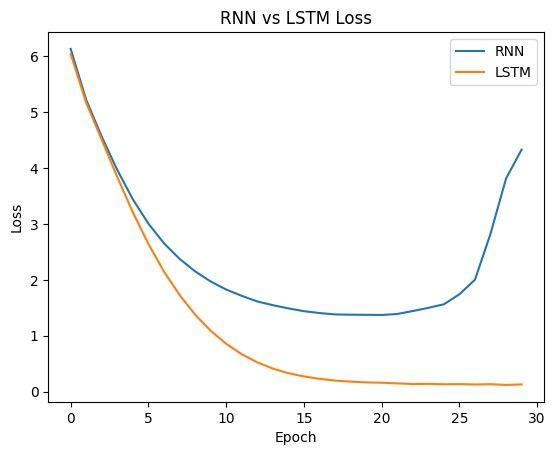

In [24]:
import matplotlib.pyplot as plt

plt.plot(rnn_losses)
plt.plot(lstm_losses)

plt.title("RNN vs LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["RNN", "LSTM"])

plt.show()

In [31]:
def generate_text(model, seed_text, length, device):
    model.eval()

    words = seed_text.lower().split()
    words = [w for w in words if w in word_to_idx]

    if len(words) == 0:
        return "Seed words not found."

    input_seq = [word_to_idx[w] for w in words]

    for _ in range(length):

        if len(input_seq) < 99:
            padded = [0]*(99 - len(input_seq)) + input_seq
        else:
            padded = input_seq[-99:]

        input_tensor = torch.tensor([padded], dtype=torch.long).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            predicted_idx = torch.argmax(output, dim=1).item()
            predicted_word = idx_to_word[predicted_idx]

        if predicted_word == "<END>":
            words.append(".")
        else:
            words.append(predicted_word)

        input_seq.append(predicted_idx)

    return " ".join(words)

In [34]:
seed_sentences = [
    "i will explore",
    "my dream was",
    "i felt a strange",
    "at night"
]

print("\nTEXT GENERATION COMPARISON\n")

for seed in seed_sentences:
    rnn_text = generate_text(rnn_model, seed, 50, device)
    lstm_text = generate_text(lstm_model, seed, 50, device)

    print(f"Seed: {seed}")
    print("RNN :", rnn_text)
    print("LSTM:", lstm_text)
    print("-" * 50)


TEXT GENERATION COMPARISON

Seed: i will explore
RNN : i will explore unknown to the green that i gazed on the occasion and thirst . i was not whether i lived still proceed with the remembrance of the poor few besides clings of his discoveries . i learned is soothing due . it is well by the darkness within excited my reverence
LSTM: i will explore even more certain and many being must see by the extreme agitation after that hour which i almost dread a mutiny for one of the first of an old woman was but in a few minutes a tumultuous sea rolled between me and my enemy . i was unable to
--------------------------------------------------
Seed: my dream was
RNN : my dream was more painful than the world which i have left them to the court and the irresistible disastrous did i cling to drink his vengeance . i looked around me wretched believe me . i looked around me caused me how shall be calm . i had not paracelsus on the
LSTM: my dream was hideous and fell around me . sometimes when it ca